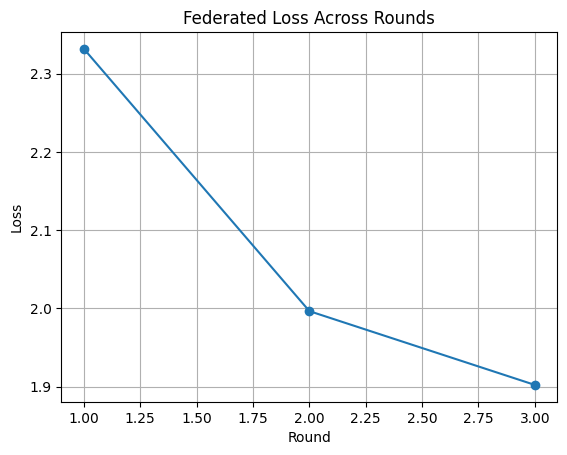

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Load log
loss_df = pd.read_csv("loss_log.txt", names=["round", "loss"])

# Plot
plt.plot(loss_df["round"], loss_df["loss"], marker="o")
plt.title("Federated Loss Across Rounds")
plt.xlabel("Round")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [2]:
import sys
sys.path.append("/Users/sandeshbhattarai/Desktop/flwr/secure_federated_learning")

from my_first_federated_learning.task import Net, load_data


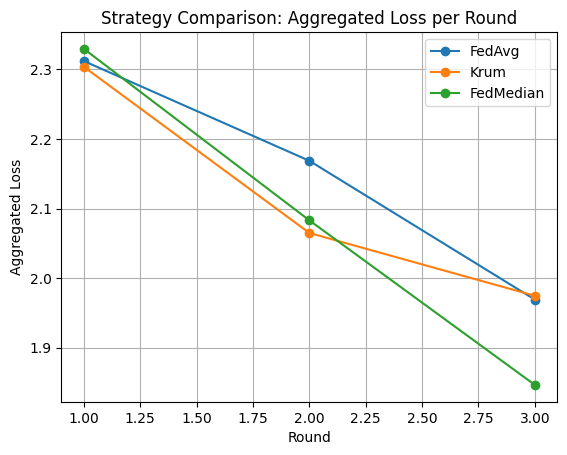

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

strategies = ["FedAvg", "Krum", "FedMedian"]

for strategy in strategies:
    df = pd.read_csv(f"loss_log_{strategy}.txt", names=["round", "loss"])
    plt.plot(df["round"], df["loss"], label=strategy, marker="o")

plt.xlabel("Round")
plt.ylabel("Aggregated Loss")
plt.title("Strategy Comparison: Aggregated Loss per Round")
plt.legend()
plt.grid(True)
plt.show()


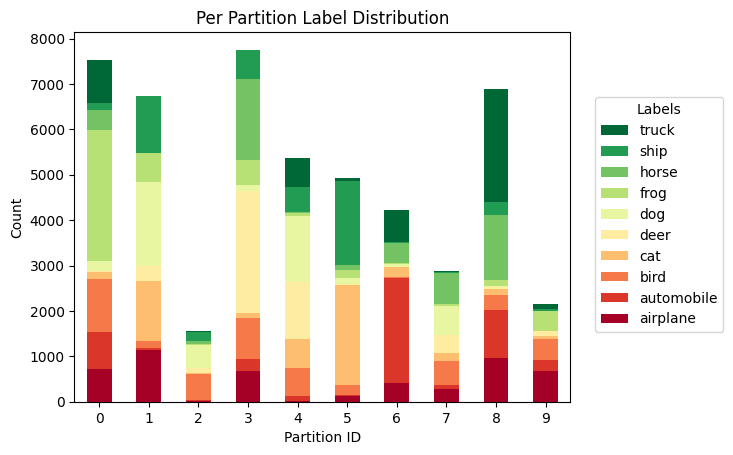

In [10]:
from flwr_datasets import FederatedDataset
from flwr_datasets.partitioner import DirichletPartitioner
from flwr_datasets.visualization import plot_label_distributions


fds = FederatedDataset(
    dataset="cifar10",
    partitioners={
        "train": DirichletPartitioner(
            num_partitions=10,
            partition_by="label",
            alpha=0.5,
            seed=42,
            min_partition_size=1000,
        ),
    },
)

partitioner = fds.partitioners["train"]

figure, axis, dataframe = plot_label_distributions(
    partitioner=partitioner,
    label_name="label",
    legend=True,
    verbose_labels=True,
)

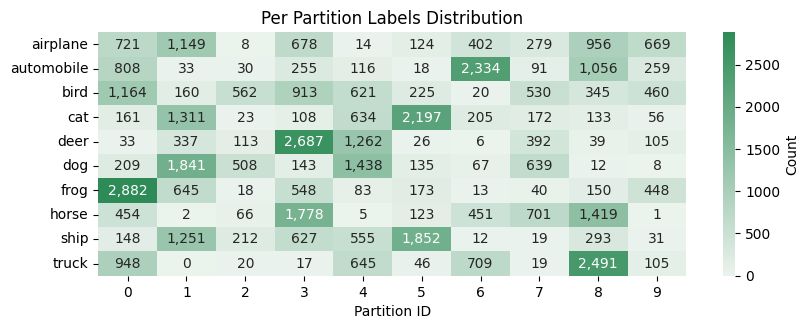

In [11]:
fig, ax, df = plot_label_distributions(
    partitioner,
    label_name="label",
    plot_type="heatmap",
    size_unit="absolute",
    partition_id_axis="x",
    legend=True,
    verbose_labels=True,
    title="Per Partition Labels Distribution",
    plot_kwargs={"annot": True},
)

Ok Now as we havbe basic idea of what is going on, we will focus on step-wise procedure for our fl model.
Lets start with data preprocessing


In [37]:
import flwr
from flwr_datasets import FederatedDataset
from flwr_datasets.partitioner import DirichletPartitioner

partitioner = DirichletPartitioner(
    num_partitions=10,
    partition_by="label",
    alpha = 0.4,
    min_partition_size=300,
    seed=42
)
fds = FederatedDataset(
    dataset="uoft-cs/cifar10",
    partitioners={"train": partitioner}
)
partition = fds.load_partition(partition_id=1)

train_test_partition = partition.train_test_split(test_size=0.2, seed=42)

from collections import Counter
labels = train_test_partition["train"]['label']
print("Client 0 label distribution:"), Counter(labels)

Client 0 label distribution:


(None,
 Counter({6: 2481,
          0: 1067,
          9: 699,
          4: 471,
          2: 117,
          1: 10,
          8: 10,
          3: 8,
          5: 7,
          7: 1}))

(['__class__',
  '__delattr__',
  '__dict__',
  '__dir__',
  '__doc__',
  '__eq__',
  '__format__',
  '__ge__',
  '__getattribute__',
  '__gt__',
  '__hash__',
  '__init__',
  '__init_subclass__',
  '__le__',
  '__lt__',
  '__module__',
  '__ne__',
  '__new__',
  '__reduce__',
  '__reduce_ex__',
  '__repr__',
  '__setattr__',
  '__sizeof__',
  '__str__',
  '__subclasshook__',
  '__weakref__',
  '_assign_dataset_to_partitioner',
  '_check_if_no_split_keyword_possible',
  '_check_if_split_possible_to_federate',
  '_check_if_split_present',
  '_check_partitioners_correctness',
  '_dataset',
  '_dataset_name',
  '_dataset_prepared',
  '_event',
  '_load_dataset_kwargs',
  '_partitioners',
  '_prepare_dataset',
  '_preprocessor',
  '_seed',
  '_shuffle',
  '_subset',
  'load_partition',
  'load_split',
  'partitioners'],
 Dataset({
     features: ['img', 'label'],
     num_rows: 6089
 }))

In [32]:
train_test_partition["train"]

Dataset({
    features: ['img', 'label'],
    num_rows: 3203
})

1

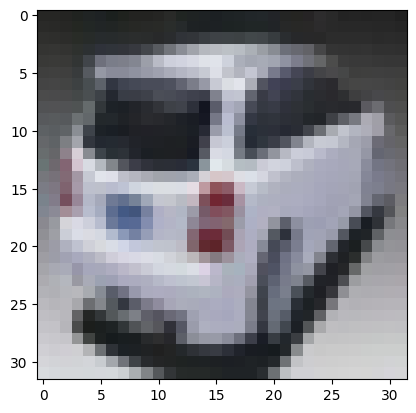

In [26]:
labels[0:10]
import matplotlib.pyplot as plt
plt.imshow(train_test_partition["train"]["img"][0])
train_test_partition["train"]["label"][0]


In [54]:
# Right now we have data in the form of PNG image, which is used by the Hugging Face to preserve the metadata.
# We need to convert it into tensors so that we can use it in PyTorch.
#We willl use a transformation. 

from torchvision import transforms
from torchvision.transforms import ToTensor, Normalize, Compose
from torch.utils.data import DataLoader
transforms = Compose([
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])




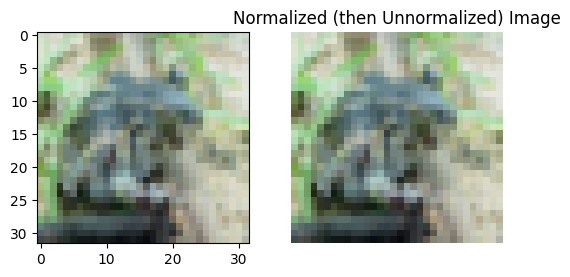

In [52]:
from torchvision.transforms import ToTensor, Normalize, Compose
import matplotlib.pyplot as plt
import numpy as np
import torch

# Sample image from CIFAR-10 (replace with your own if needed)
img = train_test_partition["train"]["img"][0]  # or use any img from your dataset
# Transform: ToTensor then Normalize
transform = Compose([
    ToTensor(),
    Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

tensor = transform(img)

# Undo normalization to visualize
def unnormalize(t):
    return t * 0.5 + 0.5  # Reverses Normalize((0.5,), (0.5,))

unnorm = unnormalize(tensor).permute(1, 2, 0).numpy()

plt.figure(figsize=(6, 6))
plt.subplot(1, 2, 1)
plt.imshow(img)

plt.subplot(1,2,2)
plt.imshow(unnorm)
plt.title("Normalized (then Unnormalized) Image")
plt.axis("off")
plt.show()


In [ ]:
# NOw as we have played around with our datasets, we will work with Model Development.
# We will be using the Pytorch to develop our CNN model.

import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1_layer_stack = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3, stride=1, padding=1),  # Adjust input_size and hidden_size
            nn.ReLU(),
            nn.Conv2d(in_channels=10, out_channels=10, kernel_size=3, stride=1, padding=1),  # Adjust input_size and hidden_size
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
        )
        self.conv2_layer_stack = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=10, kernel_size=3, stride=1, padding=1),  # Adjust input_size and hidden_size
            nn.ReLU(),
            nn.Conv2d(in_channels=10, out_channels=10, kernel_size=3, stride=1, padding=1),  # Adjust input_size and hidden_size
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.fc_layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(640, 328),  # Adjust input size based on previous layers
            nn.ReLU(),
            nn.Linear(328, 124),  # Assuming 10 classes for CIFAR-10
            nn.ReLU(),
            nn.Linear(124, 10)  # Output layer for 10 classes
        )


    def forward(self, x):
        x = self.conv1_layer_stack(x)
        x = self.conv2_layer_stack(x)
        x = self.fc_layer_stack(x)
        return x